## Hypothesis 2
A fully connected MLP will lose validation accuracy when MNIST images are shifted horizontally or vertically, and the degradation will increase as the shift distance increases. The model was trained using digits in their original locations and does not contain convolutional operations that explicitly provide translation equivariance. Consequently, moving a digit by one, two, or three pixels changes which input features connect to particular hidden units, even though the digit’s identity remains unchanged. We therefore expect validation accuracy to decrease and validation loss to increase progressively with shift distance. I will test left, right, upward, and downward shifts using zero padding, average opposite directions into horizontal and vertical conditions, and report mean ± sample standard deviation across the three saved models.

In [5]:
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from matplotlib.ticker import PercentFormatter

import scratch

importlib.reload(scratch)

from scratch import *

In [6]:
print("Loading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprocessing MNIST data...")

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
) = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)


print("\nData shapes")
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


assert X_train.shape == (50000, 784)
assert X_val.shape == (10000, 784)
assert X_test.shape == (10000, 784)

Loading MNIST data...
Preprocessing MNIST data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0

Data shapes
Training: (50000, 784) (50000,)
Validation: (10000, 784) (10000,)
Test: (10000, 784) (10000,)


In [7]:
H2_OUTPUT_DIR = Path(
    "output/hypotheses/h2_translation"
)

H2_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Checkpoints created in testing_report.ipynb.
H2_MODEL_DIR = Path(
    "output/test_reports/checkpoints"
)


H2_SEEDS = generate_experiment_seeds(
    base_seed=SPLIT_SEED,
    number_of_seeds=3
)


H2_SHIFT_DISTANCES = [
    1,
    2,
    3
]


# dx controls horizontal movement.
# dy controls vertical movement.
#
# Positive dx = right
# Negative dx = left
# Positive dy = down
# Negative dy = up
H2_DIRECTIONS = {
    "left": {
        "dx_sign": -1,
        "dy_sign": 0,
        "axis": "horizontal"
    },
    "right": {
        "dx_sign": 1,
        "dy_sign": 0,
        "axis": "horizontal"
    },
    "up": {
        "dx_sign": 0,
        "dy_sign": -1,
        "axis": "vertical"
    },
    "down": {
        "dx_sign": 0,
        "dy_sign": 1,
        "axis": "vertical"
    }
}


print("H2 output folder:", H2_OUTPUT_DIR)
print("Saved-model folder:", H2_MODEL_DIR)
print("Seeds:", H2_SEEDS)
print("Shift distances:", H2_SHIFT_DISTANCES)
print("Directions:", list(H2_DIRECTIONS))

H2 output folder: output/hypotheses/h2_translation
Saved-model folder: output/test_reports/checkpoints
Seeds: [654571, 89250, 773955]
Shift distances: [1, 2, 3]
Directions: ['left', 'right', 'up', 'down']


In [8]:
h2_models = {}
h2_checkpoint_rows = []
intialization="small"
learning_rate = "0p1"

for seed in H2_SEEDS:

    checkpoint_path = (
        H2_MODEL_DIR
        / f"best_model_init-{intialization}_lr-{learning_rate}_seed-{seed}.pt"
    )

    assert checkpoint_path.exists(), (
        f"Checkpoint not found: "
        f"{checkpoint_path}"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True
    )

    parameters = {
        parameter_name: (
            parameter_tensor
            .cpu()
            .numpy()
            .copy()
        )
        for (
            parameter_name,
            parameter_tensor
        ) in checkpoint[
            "parameters"
        ].items()
    }

    

    h2_models[seed] = {
        "parameters": parameters,
        "activation": checkpoint[
            "activation"
        ],
        "selected_epoch": checkpoint[
            "best_epoch"
        ],
        "checkpoint_path": str(
            checkpoint_path
        )
    }

    h2_checkpoint_rows.append({
        "seed": seed,
        "selected_epoch": checkpoint[
            "best_epoch"
        ],
        "validation_accuracy": checkpoint[
            "best_val_accuracy"
        ],
        "validation_loss": checkpoint[
            "best_val_loss"
        ],
        "checkpoint_path": str(
            checkpoint_path
        )
    })


h2_checkpoint_df = pd.DataFrame(
    h2_checkpoint_rows
)

display(h2_checkpoint_df)

,seed,selected_epoch,validation_accuracy,validation_loss,checkpoint_path
0,654571,75,0.9800,0.072569,output/test_reports/checkpoints/best_model_ini...
1,89250,68,0.9795,0.075936,output/test_reports/checkpoints/best_model_ini...
2,773955,80,0.9789,0.074269,output/test_reports/checkpoints/best_model_ini...


In [9]:
def h2_shift_images(
    X,
    dx=0,
    dy=0
):
    """
    Shift flattened 28x28 images with zero padding.

    dx > 0: shift right
    dx < 0: shift left
    dy > 0: shift down
    dy < 0: shift up
    """

    if abs(dx) >= 28 or abs(dy) >= 28:
        raise ValueError(
            "Shift must be smaller than 28 pixels."
        )

    images = X.reshape(
        -1,
        28,
        28
    )

    shifted_images = np.zeros_like(
        images
    )

    # Horizontal source and destination boundaries
    source_x_start = max(0, -dx)
    source_x_end = min(28, 28 - dx)

    destination_x_start = max(0, dx)
    destination_x_end = (
        destination_x_start
        + source_x_end
        - source_x_start
    )

    # Vertical source and destination boundaries
    source_y_start = max(0, -dy)
    source_y_end = min(28, 28 - dy)

    destination_y_start = max(0, dy)
    destination_y_end = (
        destination_y_start
        + source_y_end
        - source_y_start
    )

    shifted_images[
        :,
        destination_y_start:destination_y_end,
        destination_x_start:destination_x_end
    ] = images[
        :,
        source_y_start:source_y_end,
        source_x_start:source_x_end
    ]

    return shifted_images.reshape(
        X.shape[0],
        -1
    )

Saved: output/hypotheses/h2_translation/h2_original_vs_shifted_examples.png


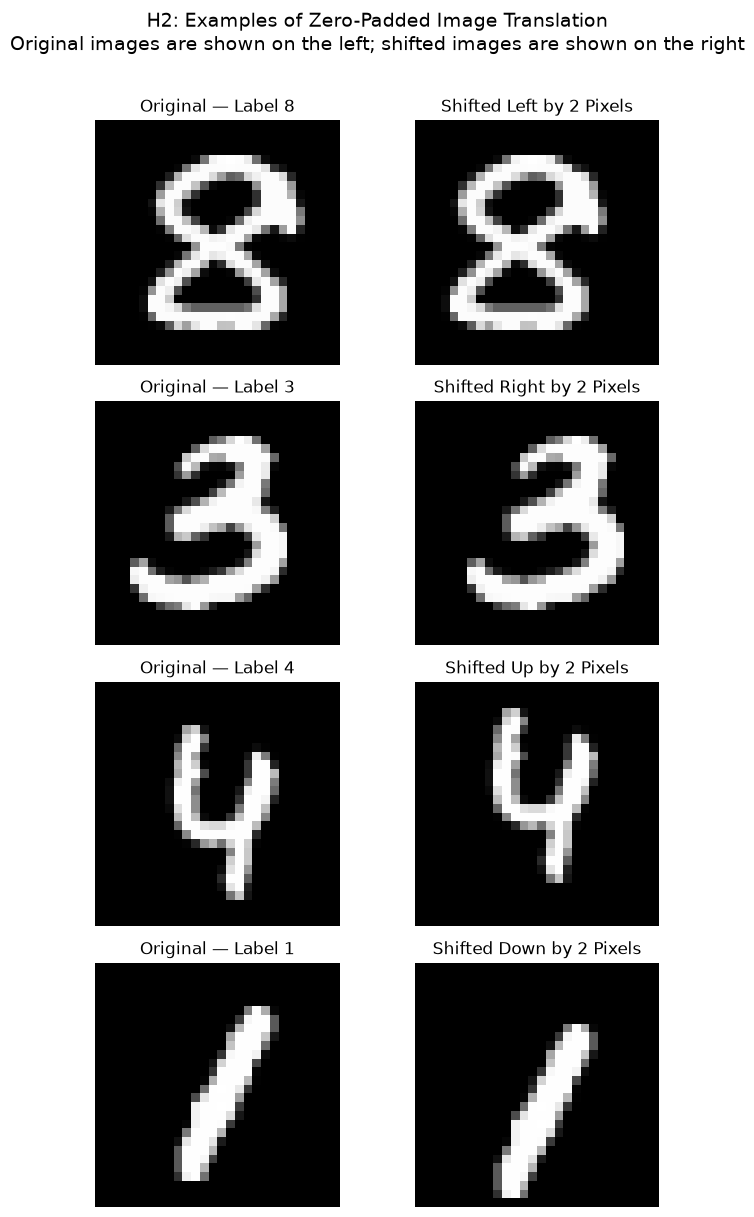

In [10]:
# ============================================================
# VISUALIZE ORIGINAL AND SHIFTED MNIST EXAMPLES
# ============================================================

H2_EXAMPLE_DISTANCE = 2

H2_EXAMPLE_DIRECTIONS = [
    "left",
    "right",
    "up",
    "down"
]


# Select four reproducible validation examples.
h2_example_rng = np.random.default_rng(
    SPLIT_SEED
)

h2_example_indices = h2_example_rng.choice(
    X_val.shape[0],
    size=len(H2_EXAMPLE_DIRECTIONS),
    replace=False
)


fig, axes = plt.subplots(
    nrows=len(H2_EXAMPLE_DIRECTIONS),
    ncols=2,
    figsize=(7, 12)
)


for row_index, (
    example_index,
    direction_name
) in enumerate(
    zip(
        h2_example_indices,
        H2_EXAMPLE_DIRECTIONS
    )
):
    direction_information = (
        H2_DIRECTIONS[
            direction_name
        ]
    )

    dx = (
        direction_information[
            "dx_sign"
        ]
        * H2_EXAMPLE_DISTANCE
    )

    dy = (
        direction_information[
            "dy_sign"
        ]
        * H2_EXAMPLE_DISTANCE
    )

    original_image = X_val[
        example_index
    ]

    shifted_image = h2_shift_images(
        X_val[
            example_index:
            example_index + 1
        ],
        dx=dx,
        dy=dy
    )[0]

    true_label = y_val[
        example_index
    ]

    # --------------------------------------------------------
    # Left column: original image
    # --------------------------------------------------------

    axes[row_index, 0].imshow(
        original_image.reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row_index, 0].set_title(
        f"Original — Label {true_label}"
    )

    axes[row_index, 0].axis("off")

    # --------------------------------------------------------
    # Right column: shifted image
    # --------------------------------------------------------

    axes[row_index, 1].imshow(
        shifted_image.reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row_index, 1].set_title(
        f"Shifted {direction_name.capitalize()} "
        f"by {H2_EXAMPLE_DISTANCE} Pixels"
    )

    axes[row_index, 1].axis("off")


fig.suptitle(
    "H2: Examples of Zero-Padded Image Translation\n"
    "Original images are shown on the left; "
    "shifted images are shown on the right",
    fontsize=14,
    y=1.01
)

plt.tight_layout()


h2_comparison_figure_path = (
    H2_OUTPUT_DIR
    / "h2_original_vs_shifted_examples.png"
)


fig.savefig(
    h2_comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)


print(
    "Saved:",
    h2_comparison_figure_path
)

plt.show()
plt.close(fig)

Saved: output/hypotheses/h2_translation/h2_translation_example.png


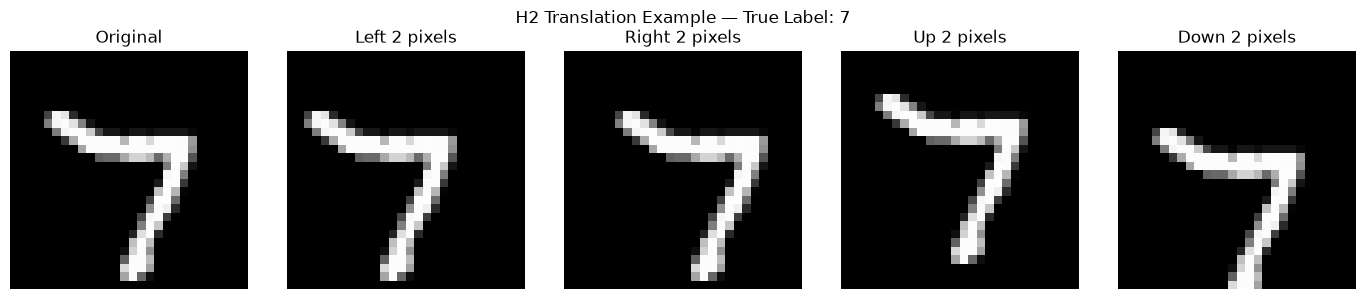

In [11]:
example_index = 0
example_distance = 2


example_images = {
    "Original": X_val[
        example_index
    ],
    "Left 2 pixels": h2_shift_images(
        X_val[example_index:example_index + 1],
        dx=-example_distance,
        dy=0
    )[0],
    "Right 2 pixels": h2_shift_images(
        X_val[example_index:example_index + 1],
        dx=example_distance,
        dy=0
    )[0],
    "Up 2 pixels": h2_shift_images(
        X_val[example_index:example_index + 1],
        dx=0,
        dy=-example_distance
    )[0],
    "Down 2 pixels": h2_shift_images(
        X_val[example_index:example_index + 1],
        dx=0,
        dy=example_distance
    )[0]
}


fig, axes = plt.subplots(
    1,
    5,
    figsize=(14, 3)
)


for axis, (
    title,
    flattened_image
) in zip(
    axes,
    example_images.items()
):
    axis.imshow(
        flattened_image.reshape(28, 28),
        cmap="gray"
    )

    axis.set_title(title)
    axis.axis("off")


fig.suptitle(
    f"H2 Translation Example — "
    f"True Label: {y_val[example_index]}"
)

plt.tight_layout()


h2_example_path = (
    H2_OUTPUT_DIR
    / "h2_translation_example.png"
)

fig.savefig(
    h2_example_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", h2_example_path)

plt.show()
plt.close(fig)

In [12]:
def h2_evaluate_shift_conditions(
    X,
    y,
    dataset_name,
    models,
    shift_distances,
    directions
):
    rows = []

    # --------------------------------------------------------
    # Clean, unshifted evaluation
    # --------------------------------------------------------

    for seed, model_information in models.items():

        clean_loss, clean_accuracy = evaluate_model(
            X,
            y,
            model_information["parameters"],
            model_information["activation"]
        )

        rows.append({
            "dataset": dataset_name,
            "seed": seed,
            "direction": "clean",
            "axis": "clean",
            "distance": 0,
            "dx": 0,
            "dy": 0,
            "loss": clean_loss,
            "accuracy": clean_accuracy
        })

        print(
            f"{dataset_name} | "
            f"seed={seed} | clean | "
            f"loss={clean_loss:.4f} | "
            f"accuracy="
            f"{100 * clean_accuracy:.2f}%"
        )

    # --------------------------------------------------------
    # Shifted evaluation
    # --------------------------------------------------------

    for distance in shift_distances:

        for (
            direction_name,
            direction_information
        ) in directions.items():

            dx = (
                direction_information[
                    "dx_sign"
                ] * distance
            )

            dy = (
                direction_information[
                    "dy_sign"
                ] * distance
            )

            shifted_X = h2_shift_images(
                X,
                dx=dx,
                dy=dy
            )

            for (
                seed,
                model_information
            ) in models.items():

                shifted_loss, shifted_accuracy = (
                    evaluate_model(
                        shifted_X,
                        y,
                        model_information[
                            "parameters"
                        ],
                        model_information[
                            "activation"
                        ]
                    )
                )

                rows.append({
                    "dataset": dataset_name,
                    "seed": seed,
                    "direction": direction_name,
                    "axis": direction_information[
                        "axis"
                    ],
                    "distance": distance,
                    "dx": dx,
                    "dy": dy,
                    "loss": shifted_loss,
                    "accuracy": shifted_accuracy
                })

                print(
                    f"{dataset_name} | "
                    f"seed={seed} | "
                    f"{direction_name} "
                    f"{distance}px | "
                    f"loss={shifted_loss:.4f} | "
                    f"accuracy="
                    f"{100 * shifted_accuracy:.2f}%"
                )

    return pd.DataFrame(rows)

In [13]:
h2_validation_raw_df = (
    h2_evaluate_shift_conditions(
        X=X_val,
        y=y_val,
        dataset_name="validation",
        models=h2_models,
        shift_distances=H2_SHIFT_DISTANCES,
        directions=H2_DIRECTIONS
    )
)


print("\nNumber of validation evaluations:")

print(
    len(h2_validation_raw_df)
)

display(
    h2_validation_raw_df.head()
)

validation | seed=654571 | clean | loss=0.0726 | accuracy=98.00%
validation | seed=89250 | clean | loss=0.0759 | accuracy=97.95%
validation | seed=773955 | clean | loss=0.0743 | accuracy=97.89%
validation | seed=654571 | left 1px | loss=0.1588 | accuracy=95.61%
validation | seed=89250 | left 1px | loss=0.1668 | accuracy=95.39%
validation | seed=773955 | left 1px | loss=0.1735 | accuracy=95.26%
validation | seed=654571 | right 1px | loss=0.1527 | accuracy=95.78%
validation | seed=89250 | right 1px | loss=0.1491 | accuracy=95.79%
validation | seed=773955 | right 1px | loss=0.1508 | accuracy=95.87%
validation | seed=654571 | up 1px | loss=0.1923 | accuracy=95.08%
validation | seed=89250 | up 1px | loss=0.1912 | accuracy=94.90%
validation | seed=773955 | up 1px | loss=0.2018 | accuracy=94.71%
validation | seed=654571 | down 1px | loss=0.1711 | accuracy=95.54%
validation | seed=89250 | down 1px | loss=0.1753 | accuracy=95.14%
validation | seed=773955 | down 1px | loss=0.1758 | accuracy=95.3

,dataset,seed,direction,axis,distance,dx,dy,loss,accuracy
0,validation,654571,clean,clean,0,0,0,0.072569,0.9800
1,validation,89250,clean,clean,0,0,0,0.075936,0.9795
2,validation,773955,clean,clean,0,0,0,0.074269,0.9789
3,validation,654571,left,horizontal,1,-1,0,0.158779,0.9561
4,validation,89250,left,horizontal,1,-1,0,0.166793,0.9539


In [15]:

def h2_create_axis_summary(
    raw_results_df
):
    axis_rows = []

    # Duplicate the clean result for both axes so that
    # horizontal and vertical curves begin at the same point.
    clean_rows = raw_results_df[
        raw_results_df["distance"] == 0
    ]

    for _, row in clean_rows.iterrows():

        for axis_name in [
            "horizontal",
            "vertical"
        ]:
            axis_rows.append({
                "dataset": row["dataset"],
                "seed": row["seed"],
                "axis": axis_name,
                "distance": 0,
                "loss": row["loss"],
                "accuracy": row["accuracy"]
            })

    # For shifted conditions, average the two opposite
    # directions for each axis within each seed.
    shifted_rows = raw_results_df[
        raw_results_df["distance"] > 0
    ]

    shifted_axis_seed_df = (
        shifted_rows
        .groupby(
            [
                "dataset",
                "seed",
                "axis",
                "distance"
            ],
            as_index=False
        )
        .agg(
            loss=("loss", "mean"),
            accuracy=("accuracy", "mean")
        )
    )

    axis_seed_df = pd.concat(
        [
            pd.DataFrame(axis_rows),
            shifted_axis_seed_df
        ],
        ignore_index=True
    )

    # Add accuracy/loss changes relative to the clean
    # performance of the same model.
    clean_accuracy_by_seed = (
        clean_rows
        .set_index("seed")["accuracy"]
        .to_dict()
    )

    clean_loss_by_seed = (
        clean_rows
        .set_index("seed")["loss"]
        .to_dict()
    )

    axis_seed_df[
        "accuracy_drop"
    ] = axis_seed_df.apply(
        lambda row: (
            clean_accuracy_by_seed[
                row["seed"]
            ] - row["accuracy"]
        ),
        axis=1
    )

    axis_seed_df[
        "loss_increase"
    ] = axis_seed_df.apply(
        lambda row: (
            row["loss"]
            - clean_loss_by_seed[
                row["seed"]
            ]
        ),
        axis=1
    )

    axis_summary_df = (
        axis_seed_df
        .groupby(
            [
                "dataset",
                "axis",
                "distance"
            ],
            as_index=False
        )
        .agg(
            loss_mean=("loss", "mean"),
            loss_std=("loss", "std"),
            accuracy_mean=(
                "accuracy",
                "mean"
            ),
            accuracy_std=(
                "accuracy",
                "std"
            ),
            accuracy_drop_mean=(
                "accuracy_drop",
                "mean"
            ),
            accuracy_drop_std=(
                "accuracy_drop",
                "std"
            ),
            loss_increase_mean=(
                "loss_increase",
                "mean"
            ),
            loss_increase_std=(
                "loss_increase",
                "std"
            )
        )
    )

    return (
        axis_seed_df,
        axis_summary_df
    )
(
    h2_validation_axis_seed_df,
    h2_validation_summary_df
) = h2_create_axis_summary(
    h2_validation_raw_df
)

In [16]:
h2_validation_display_rows = []


for _, row in (
    h2_validation_summary_df
    .sort_values(
        ["axis", "distance"]
    )
    .iterrows()
):

    h2_validation_display_rows.append({
        "Shift Axis": row["axis"],
        "Distance": (
            f"{int(row['distance'])} pixels"
        ),
        "Validation Accuracy": (
            f"{100 * row['accuracy_mean']:.2f}% "
            f"± "
            f"{100 * row['accuracy_std']:.2f}%"
        ),
        "Accuracy Drop": (
            f"{100 * row['accuracy_drop_mean']:.2f} "
            f"± "
            f"{100 * row['accuracy_drop_std']:.2f} "
            "points"
        ),
        "Validation Loss": (
            f"{row['loss_mean']:.4f} "
            f"± {row['loss_std']:.4f}"
        ),
        "Loss Increase": (
            f"{row['loss_increase_mean']:.4f} "
            f"± "
            f"{row['loss_increase_std']:.4f}"
        )
    })


h2_validation_display_df = pd.DataFrame(
    h2_validation_display_rows
)


print(
    "H2 VALIDATION RESULTS: "
    "MEAN ± SAMPLE STANDARD DEVIATION"
)

display(h2_validation_display_df)

H2 VALIDATION RESULTS: MEAN ± SAMPLE STANDARD DEVIATION


,Shift Axis,Distance,Validation Accuracy,Accuracy Drop,Validation Loss,Loss Increase
0,horizontal,0 pixels,97.95% ± 0.06%,0.00 ± 0.00 points,0.0743 ± 0.0017,0.0000 ± 0.0000
1,horizontal,1 pixels,95.62% ± 0.07%,2.33 ± 0.03 points,0.1586 ± 0.0033,0.0844 ± 0.0031
2,horizontal,2 pixels,82.76% ± 0.07%,15.18 ± 0.04 points,0.7124 ± 0.0223,0.6382 ± 0.0228
3,horizontal,3 pixels,59.55% ± 0.93%,38.40 ± 0.94 points,2.1755 ± 0.1019,2.1012 ± 0.1031
4,vertical,0 pixels,97.95% ± 0.06%,0.00 ± 0.00 points,0.0743 ± 0.0017,0.0000 ± 0.0000
5,vertical,1 pixels,95.12% ± 0.16%,2.83 ± 0.12 points,0.1846 ± 0.0037,0.1103 ± 0.0037
6,vertical,2 pixels,80.94% ± 0.31%,17.00 ± 0.26 points,0.8846 ± 0.0277,0.8103 ± 0.0276
7,vertical,3 pixels,52.26% ± 0.44%,45.69 ± 0.40 points,3.0193 ± 0.0745,2.9450 ± 0.0749


In [18]:
def h2_plot_shift_results(
    summary_df,
    dataset_label,
    output_directory
):
    axis_colors = {
        "horizontal": "tab:blue",
        "vertical": "tab:orange"
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.5)
    )

    for axis_name in [
        "horizontal",
        "vertical"
    ]:
        axis_data = (
            summary_df[
                summary_df["axis"]
                == axis_name
            ]
            .sort_values("distance")
        )

        distances = axis_data[
            "distance"
        ].to_numpy()

        accuracy_mean = axis_data[
            "accuracy_mean"
        ].to_numpy()

        accuracy_std = axis_data[
            "accuracy_std"
        ].to_numpy()

        loss_mean = axis_data[
            "loss_mean"
        ].to_numpy()

        loss_std = axis_data[
            "loss_std"
        ].to_numpy()

        color = axis_colors[
            axis_name
        ]

        axes[0].errorbar(
            distances,
            accuracy_mean,
            yerr=accuracy_std,
            marker="o",
            linewidth=2,
            capsize=5,
            color=color,
            label=axis_name.capitalize()
        )

        axes[1].errorbar(
            distances,
            loss_mean,
            yerr=loss_std,
            marker="o",
            linewidth=2,
            capsize=5,
            color=color,
            label=axis_name.capitalize()
        )

    axes[0].set_title(
        f"{dataset_label} Accuracy"
    )

    axes[0].set_xlabel(
        "Shift Distance (Pixels)"
    )

    axes[0].set_ylabel("Accuracy")

    axes[0].yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )

    axes[0].set_xticks([0, 1, 2, 3])
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].set_title(
        f"{dataset_label} Loss"
    )

    axes[1].set_xlabel(
        "Shift Distance (Pixels)"
    )

    axes[1].set_ylabel(
        "Cross-Entropy Loss"
    )

    axes[1].set_xticks([0, 1, 2, 3])
    axes[1].set_ylim(bottom=0)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.suptitle(
        "H2: Effect of Image Translation\n"
        "Points show the mean of 3 seeds; "
        "error bars show ±1 sample standard deviation",
        fontsize=14
    )

    plt.tight_layout()

    safe_dataset_name = (
        dataset_label.lower()
    )

    png_path = (
        output_directory
        / (
            f"h2_{safe_dataset_name}_"
            "translation_results.png"
        )
    )

    pdf_path = (
        output_directory
        / (
            f"h2_{safe_dataset_name}_"
            "translation_results.pdf"
        )
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    print("Saved:", png_path)
    print("Saved:", pdf_path)

    plt.show()
    plt.close(fig)

Saved: output/hypotheses/h2_translation/h2_validation_translation_results.png
Saved: output/hypotheses/h2_translation/h2_validation_translation_results.pdf


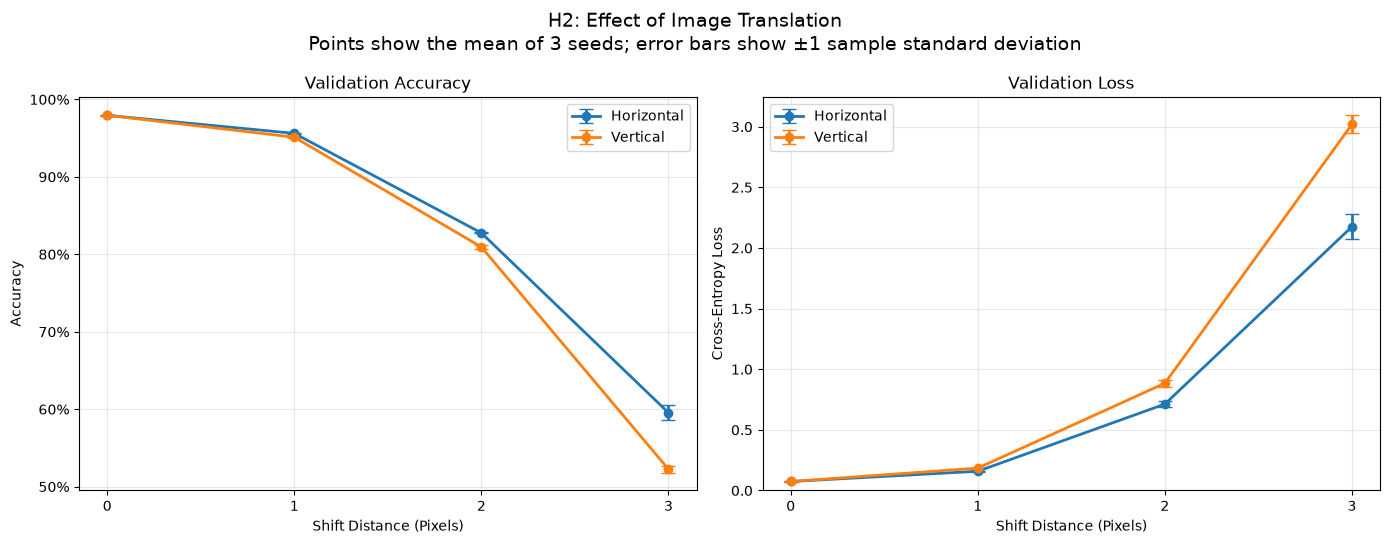

In [19]:
h2_plot_shift_results(
    summary_df=h2_validation_summary_df,
    dataset_label="Validation",
    output_directory=H2_OUTPUT_DIR
)

In [20]:
for axis_name in [
    "horizontal",
    "vertical"
]:

    axis_data = (
        h2_validation_summary_df[
            h2_validation_summary_df[
                "axis"
            ] == axis_name
        ]
        .sort_values("distance")
    )

    accuracies = axis_data[
        "accuracy_mean"
    ].to_numpy()

    losses = axis_data[
        "loss_mean"
    ].to_numpy()

    accuracy_is_monotonic = np.all(
        np.diff(accuracies) <= 0
    )

    loss_is_monotonic = np.all(
        np.diff(losses) >= 0
    )

    clean_accuracy = accuracies[0]
    three_pixel_accuracy = accuracies[-1]

    total_accuracy_drop = (
        clean_accuracy
        - three_pixel_accuracy
    )

    print("\nShift axis:", axis_name)

    print(
        "Accuracy decreases monotonically:",
        bool(accuracy_is_monotonic)
    )

    print(
        "Loss increases monotonically:",
        bool(loss_is_monotonic)
    )

    print(
        "Accuracy drop at 3 pixels:",
        f"{100 * total_accuracy_drop:.2f} "
        "percentage points"
    )


Shift axis: horizontal
Accuracy decreases monotonically: True
Loss increases monotonically: True
Accuracy drop at 3 pixels: 38.40 percentage points

Shift axis: vertical
Accuracy decreases monotonically: True
Loss increases monotonically: True
Accuracy drop at 3 pixels: 45.69 percentage points


In [21]:
h2_validation_raw_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_validation_results_raw.csv",
    index=False
)

h2_validation_axis_seed_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_validation_results_by_seed.csv",
    index=False
)

h2_validation_summary_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_validation_summary_numeric.csv",
    index=False
)

h2_validation_display_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_validation_summary_formatted.csv",
    index=False
)

h2_checkpoint_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_model_checkpoints.csv",
    index=False
)

print("Validation results saved.")

Validation results saved.


test | seed=654571 | clean | loss=0.0716 | accuracy=97.81%
test | seed=89250 | clean | loss=0.0716 | accuracy=97.89%
test | seed=773955 | clean | loss=0.0719 | accuracy=97.84%
test | seed=654571 | left 1px | loss=0.1412 | accuracy=95.91%
test | seed=89250 | left 1px | loss=0.1481 | accuracy=95.54%
test | seed=773955 | left 1px | loss=0.1538 | accuracy=95.37%
test | seed=654571 | right 1px | loss=0.1436 | accuracy=96.20%
test | seed=89250 | right 1px | loss=0.1380 | accuracy=96.30%
test | seed=773955 | right 1px | loss=0.1426 | accuracy=96.30%
test | seed=654571 | up 1px | loss=0.1828 | accuracy=95.23%
test | seed=89250 | up 1px | loss=0.1776 | accuracy=95.09%
test | seed=773955 | up 1px | loss=0.1886 | accuracy=94.90%
test | seed=654571 | down 1px | loss=0.1557 | accuracy=95.70%
test | seed=89250 | down 1px | loss=0.1558 | accuracy=95.74%
test | seed=773955 | down 1px | loss=0.1623 | accuracy=95.63%
test | seed=654571 | left 2px | loss=0.7446 | accuracy=82.21%
test | seed=89250 | left 

,Shift Axis,Distance,Test Accuracy,Accuracy Drop,Test Loss
0,horizontal,0 pixels,97.85% ± 0.04%,0.00 ± 0.00 points,0.0717 ± 0.0001
1,horizontal,1 pixels,95.94% ± 0.11%,1.91 ± 0.14 points,0.1446 ± 0.0032
2,horizontal,2 pixels,83.52% ± 0.06%,14.33 ± 0.10 points,0.6735 ± 0.0211
3,horizontal,3 pixels,60.20% ± 0.86%,37.65 ± 0.82 points,2.1413 ± 0.1103
4,vertical,0 pixels,97.85% ± 0.04%,0.00 ± 0.00 points,0.0717 ± 0.0001
5,vertical,1 pixels,95.38% ± 0.10%,2.46 ± 0.12 points,0.1705 ± 0.0045
6,vertical,2 pixels,81.90% ± 0.40%,15.95 ± 0.44 points,0.8441 ± 0.0226
7,vertical,3 pixels,53.42% ± 0.34%,44.42 ± 0.34 points,2.9410 ± 0.0796


Saved: output/hypotheses/h2_translation/h2_test_translation_results.png
Saved: output/hypotheses/h2_translation/h2_test_translation_results.pdf


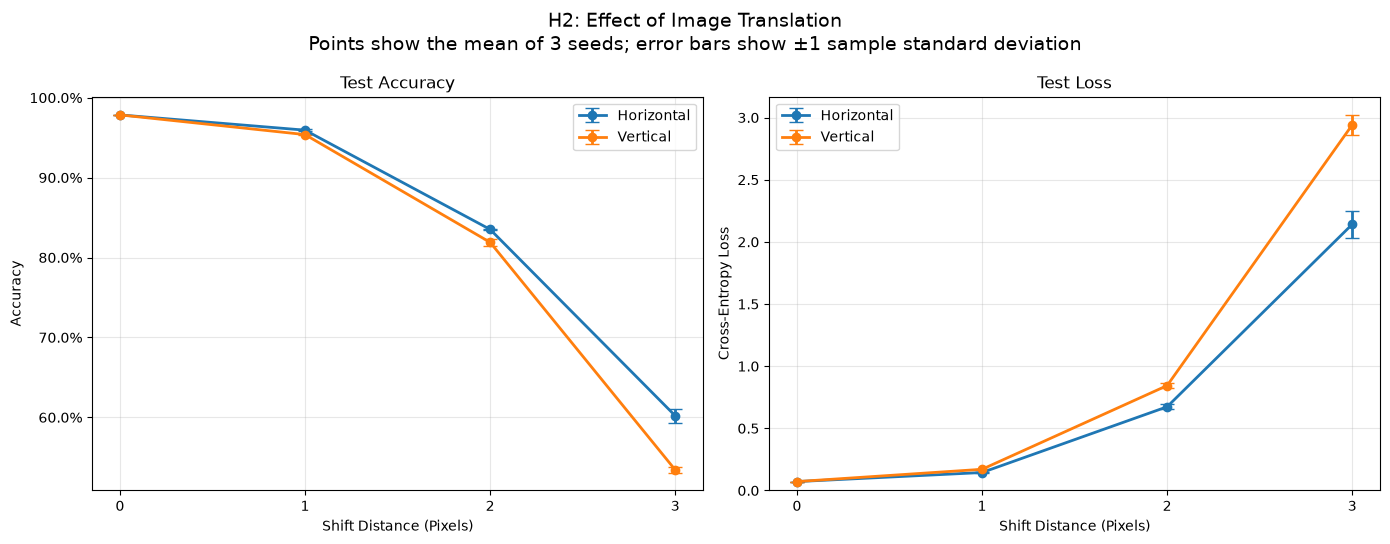


Saved H2 files:
- output/hypotheses/h2_translation/h2_model_checkpoints.csv
- output/hypotheses/h2_translation/h2_original_vs_shifted_examples.png
- output/hypotheses/h2_translation/h2_test_results_by_seed.csv
- output/hypotheses/h2_translation/h2_test_results_raw.csv
- output/hypotheses/h2_translation/h2_test_summary_formatted.csv
- output/hypotheses/h2_translation/h2_test_summary_numeric.csv
- output/hypotheses/h2_translation/h2_test_translation_results.pdf
- output/hypotheses/h2_translation/h2_test_translation_results.png
- output/hypotheses/h2_translation/h2_translation_example.png
- output/hypotheses/h2_translation/h2_validation_results_by_seed.csv
- output/hypotheses/h2_translation/h2_validation_results_raw.csv
- output/hypotheses/h2_translation/h2_validation_summary_formatted.csv
- output/hypotheses/h2_translation/h2_validation_summary_numeric.csv
- output/hypotheses/h2_translation/h2_validation_translation_results.pdf
- output/hypotheses/h2_translation/h2_validation_translatio

In [22]:
# ============================================================
# H2 FINAL CONFIRMATORY TEST
# ============================================================

h2_test_raw_df = (
    h2_evaluate_shift_conditions(
        X=X_test,
        y=y_test,
        dataset_name="test",
        models=h2_models,
        shift_distances=H2_SHIFT_DISTANCES,
        directions=H2_DIRECTIONS
    )
)


(
    h2_test_axis_seed_df,
    h2_test_summary_df
) = h2_create_axis_summary(
    h2_test_raw_df
)


h2_test_display_rows = []


for _, row in (
    h2_test_summary_df
    .sort_values(
        ["axis", "distance"]
    )
    .iterrows()
):

    h2_test_display_rows.append({
        "Shift Axis": row["axis"],
        "Distance": (
            f"{int(row['distance'])} pixels"
        ),
        "Test Accuracy": (
            f"{100 * row['accuracy_mean']:.2f}% "
            f"± "
            f"{100 * row['accuracy_std']:.2f}%"
        ),
        "Accuracy Drop": (
            f"{100 * row['accuracy_drop_mean']:.2f} "
            f"± "
            f"{100 * row['accuracy_drop_std']:.2f} "
            "points"
        ),
        "Test Loss": (
            f"{row['loss_mean']:.4f} "
            f"± {row['loss_std']:.4f}"
        )
    })


h2_test_display_df = pd.DataFrame(
    h2_test_display_rows
)


print(
    "H2 FINAL TEST RESULTS: "
    "MEAN ± SAMPLE STANDARD DEVIATION"
)

display(h2_test_display_df)


h2_plot_shift_results(
    summary_df=h2_test_summary_df,
    dataset_label="Test",
    output_directory=H2_OUTPUT_DIR
)


h2_test_raw_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_test_results_raw.csv",
    index=False
)

h2_test_axis_seed_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_test_results_by_seed.csv",
    index=False
)

h2_test_summary_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_test_summary_numeric.csv",
    index=False
)

h2_test_display_df.to_csv(
    H2_OUTPUT_DIR
    / "h2_test_summary_formatted.csv",
    index=False
)


print("\nSaved H2 files:")

for saved_file in sorted(
    H2_OUTPUT_DIR.iterdir()
):
    print("-", saved_file)